In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
n = 300

temperature = np.random.uniform(15, 35, n)

weather_types = ['Sunny', 'Cloudy', 'Rainy']
weather = np.random.choice(weather_types, size=n, p=[0.4, 0.4, 0.2])

# Base sales: 50
# Temperature effect: +5
# Weather Effect (Hidden coefficients):
#   - Sunny: +40 extra sales
#   - Cloudy: +10 extra sales
#   - Rainy: -20 sales (decrease)
sales = 50 + (temperature * 5)
# Let's manually add the weather effect (using numpy masking)
sales[weather == 'Sunny'] += 40
sales[weather == 'Cloudy'] += 10
sales[weather == 'Rainy'] -= 20

# Adding some noise
sales += np.random.normal(0, 10, n)

# DataFrame
df = pd.DataFrame({
    'Temperature': temperature,
    'Weather': weather,
    'Sales': sales
})

print("Raw Data:")
print(df.head())

Raw Data:
   Temperature Weather       Sales
0    22.490802   Sunny  197.151436
1    34.014286  Cloudy  222.142702
2    29.639879  Cloudy  207.129091
3    26.973170  Cloudy  184.513425
4    18.120373  Cloudy  145.065371


In [3]:
# drop_first=True to avoid dummy variable trap
df_encoded = pd.get_dummies(df, columns=['Weather'], drop_first=True)

# Convert dummies to int type for clarity
df_encoded = df_encoded.astype(int) 
# Note: Sales and Temperature columns are already numeric, so they remain unchanged; only the 0/1 columns become int.

print("Encoded (Processed) Data:")
print(df_encoded.head())

Encoded (Processed) Data:
   Temperature  Sales  Weather_Rainy  Weather_Sunny
0           22    197              0              1
1           34    222              0              0
2           29    207              0              0
3           26    184              0              0
4           18    145              0              0


In [4]:
X = df_encoded.drop('Sales', axis=1) # All except Sales
y = df_encoded['Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Model successfully trained.")

Model successfully trained.


In [5]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Effect (Coefficient)'])
print(f"Constant (Intercept): {model.intercept_:.2f}")
print(coefficients)

Constant (Intercept): 66.45
               Effect (Coefficient)
Temperature                4.824295
Weather_Rainy            -33.216891
Weather_Sunny             30.589960


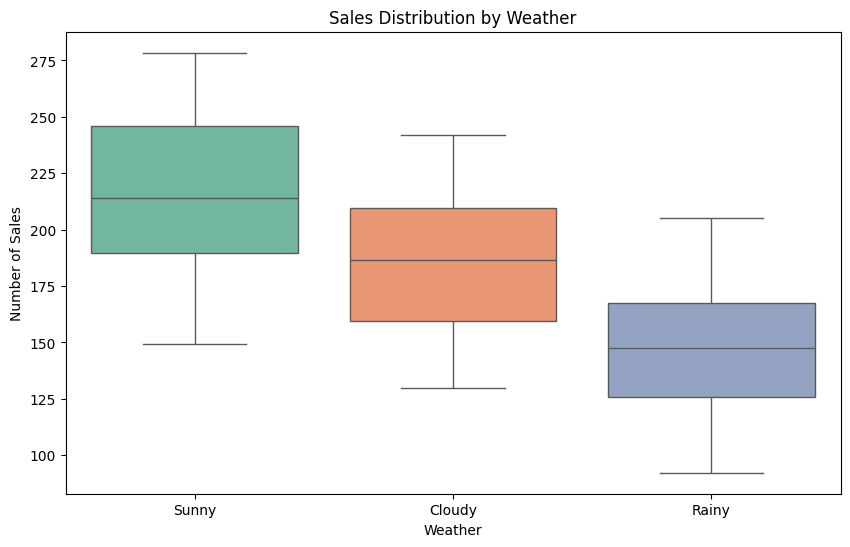

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Weather', y='Sales', data=df, palette='Set2')
plt.title('Sales Distribution by Weather')
plt.ylabel('Number of Sales')
plt.show()

In [ ]:
# Scenario: Temperature 25 degrees, Weather SUNNY
# Sunny column will be 1, Rainy column will be 0.
new_data = [[25, 0, 1]] 

prediction = model.predict(new_data)
print(f"Temperature 25°C and Weather Sunny, Prediction: {int(prediction[0])} ice creams.")

# Scenario 2: Temperature 20 degrees, Weather CLOUDY
# Cloudy is our "hidden" reference. So we give 0 to both.
new_data_cloudy = [[20, 0, 0]]
prediction_cloudy = model.predict(new_data_cloudy)
print(f"Temperature 20°C and Weather Cloudy, Prediction: {int(prediction_cloudy[0])} ice creams.")

Temperature 25°C and Weather Sunny, Prediction: 217 ice creams.
Temperature 20°C and Weather Cloudy, Prediction: 162 ice creams.


: 